In [2]:
# Import libraries
import xarray as xr
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
sst_file_path = r"D:\\NITD\\2nd Sem\\Computational Simulation Lab\\ERA5_SST_sst_K_monmean_7924_1.nc"
data = xr.open_dataset(sst_file_path)



In [ ]:
# Step 2: Preprocess
sst_data = data['sst']
sst_series = sst_data.mean(dim=['lat', 'lon']).values
time = pd.to_datetime(data['time'].values)

# Convert Kelvin → Celsius
sst_series_celsius = sst_series - 273.15

# Normalize
scaler = MinMaxScaler()
sst_norm = scaler.fit_transform(sst_series_celsius.reshape(-1, 1)).flatten()

df = pd.DataFrame({'time': time, 'sst': sst_norm}).dropna()

In [4]:
# Step 3: Stationarity test
adf = adfuller(df['sst'])
print("ADF Statistic:", adf[0])
print("p-value:", adf[1])

# Choose differencing automatically
d = 0
if adf[1] > 0.05:
    print("Series not stationary → using d=1")
    d = 1
else:
    print("Series stationary → d=0")

ADF Statistic: -0.7210620105791069
p-value: 0.8412183165515301
Series not stationary → using d=1


In [5]:
# Step 4: Train-test split
train_size = int(len(df) * 0.8)
train, test = df['sst'][:train_size], df['sst'][train_size:]

In [15]:
# Step 5: Fit ARIMA model
p = 12   # autoregressive order
q = 12  # moving average order
d=2

model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\V.Sree Chaitran\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\V.Sree Chaitran\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                    sst   No. Observations:                  441
Model:               ARIMA(12, 2, 12)   Log Likelihood                 908.387
Date:                Mon, 09 Feb 2026   AIC                          -1766.773
Time:                        15:39:49   BIC                          -1664.661
Sample:                             0   HQIC                         -1726.486
                                - 441                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4858      0.752     -0.646      0.518      -1.960       0.988
ar.L2         -0.3402      0.456     -0.746      0.456      -1.234       0.554
ar.L3         -0.5284      0.593     -0.890      0.3

c:\Users\V.Sree Chaitran\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [16]:
# Step 6: Forecast
predictions = model_fit.forecast(steps=len(test))

In [17]:
# Step 7: Evaluate
rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 0.09723467962686051


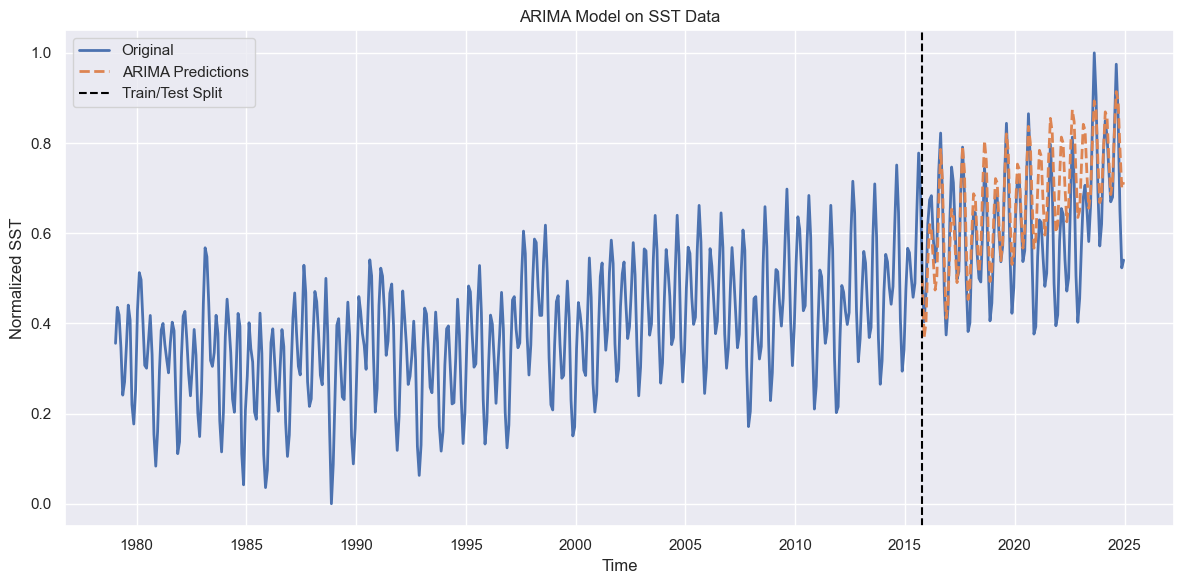

In [18]:
# Step 8: Plot
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

plt.plot(df['time'], df['sst'], label="Original", linewidth=2)
plt.plot(df['time'][train_size:], predictions,
         label="ARIMA Predictions", linestyle='--', linewidth=2)

plt.axvline(df['time'].iloc[train_size],
            color='black', linestyle='--', label="Train/Test Split")

plt.title("ARIMA Model on SST Data")
plt.xlabel("Time")
plt.ylabel("Normalized SST")
plt.legend()
plt.tight_layout()
plt.show()
